# 00_intro — Emulator Edition

This notebook is a 1:1 port of `00_intro.ipynb` that runs against the
Verilator emulator instead of a physical RFSoC. Each simulation section now
uses the emulator setup flow:

```
OUT     = ARTIFACTS_ROOT / '<name>'
soc_emu = emu.prepare_emu(memdir=OUT, build=False, trace=True)
if RUN_SIM:
    iq_list = prog.acquire_decimated(soc_emu)
```

**Skipped cells:**
- DDR4 buffer cells (`24, 25, 26`) — the TB does not instantiate the DDR4
  buffer IP.
- "Ways to run programs" + scratchwork section (`58+`) — covered by the
  build helpers above.

## Setup

In [1]:
import sys
import importlib
import pathlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# path setup
REPO_ROOT  = pathlib.Path.cwd().parent          # emulator/
sys.path.insert(0,str(REPO_ROOT / '..' / 'qick_lib/'))
source_dir = REPO_ROOT / 'software' / 'source'
if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))

import qick_emu
importlib.reload(qick_emu)          # pick up edits without kernel restart
from qick_emu import QickEmu

from qick.asm_v2 import AveragerProgramV2, QickSpan, QickSweep1D

# emulator init
CFG_PATH = REPO_ROOT / 'notebooks' / 'qick_config_216.json'
CFG_PATH = REPO_ROOT / 'notebooks' / 'qick_emu_config.json'
soc      = QickEmu(str(CFG_PATH))
soccfg   = soc.soccfg

# artifact root
ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / '00_intro'
# ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / 'qick_emu_data'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

# Master switch — set False to skip Verilator runs and re-plot from existing CSVs
RUN_SIM = True

print(f'REPO_ROOT     : {REPO_ROOT}')
print(f'ARTIFACTS_ROOT: {ARTIFACTS_ROOT}')
print(soccfg)

# Default Path is the artifacts root.
OUT = ARTIFACTS_ROOT

## QICKEmu Auxiliary Functions
def QICKEmu_plot_dac(soc_emu, OUT):
    # DAC waveform
    t_dac, dac = soc_emu.load_dac(OUT, absolute_time=True)
    t_dac_ch1, dac_ch1 = soc_emu.load_dac(emu_dir=OUT, gen_ch=1, absolute_time=True)
    plt.figure(figsize=(10, 3))
    plt.plot(t_dac, dac, linewidth=0.8)
    plt.plot(t_dac_ch1, dac_ch1, linewidth=0.8)
    plt.xlabel('time [us]'); plt.ylabel('DAC value'); plt.title('DAC output')
    plt.grid(True, ls=':'); plt.tight_layout(); plt.show()


QICK library version mismatch: 0.2.366 remote (the board), 0.2.388 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


REPO_ROOT     : /home/dmartin2/hrl-labs-clinic/qick_fork_mmdiego_qickemu/emulator
ARTIFACTS_ROOT: /home/dmartin2/hrl-labs-clinic/qick_fork_mmdiego_qickemu/emulator/artifacts/00_intro
QICK running on QICKEmu, software version 0.2.366

Firmware configuration (built Sat Sep 28 22:15:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	2 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is QICKEmu DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is QICKEmu DAC port 1

	1 readout channels:
	0:	axis_dyn_readout_v1 - configured by tProc output 4
		fs=2457.600 Msps, decimated=307.

In [2]:
# QICKEmu channel assignments
GEN_CH    = 0
RO_CH     = 0
TRIG_TIME = 0.40   # us
FREQ      = 500    # MHz
FREQ      = 100    # MHz
# FREQ      = 0    # MHz


## Basic multi-pulse program

Port of `00_intro.ipynb` cell 10. Five pulses of different styles back-to-back
through a single RO window.

In [3]:
class MultiPulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        gen_ch1 = cfg['gen_ch1']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_gen(ch=gen_ch1, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        ramp_len = 0.2
        self.add_gauss(ch=gen_ch, name='ramp',
                       sigma=ramp_len/10, length=ramp_len, even_length=True)

        self.add_pulse(ch=gen_ch, name='myflattop', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=0.1, phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch, name='mygaus', ro_ch=ro_ch,
                       style='arb', envelope='ramp',
                       freq=cfg['freq'], phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch, name='myconst', ro_ch=ro_ch,
                       style='const', length=0.2,
                       freq=cfg['freq'], phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch, name='myflattop2', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=0.1, phase=90, gain=1.0)

        self.add_pulse(ch=gen_ch1, name='myconst_ch1', ro_ch=ro_ch,
                       style='const', length=0.5,
                       freq=cfg['freq'], phase=0, gain=1.0)


        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        # NB: `ddr4=True` is a no-op in the emulator — kept so the program
        # matches the on-hardware version byte-for-byte.
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['gen_ch'], name='myflattop',  t=0)
        self.pulse(ch=cfg['gen_ch'], name='mygaus',     t=0.4)
        self.pulse(ch=cfg['gen_ch'], name='myconst',    t=0.8)
        self.pulse(ch=cfg['gen_ch'], name='myflattop2', t=1.2)
        self.pulse(ch=cfg['gen_ch'], name='mygaus',     t=1.6)
        self.pulse(ch=cfg['gen_ch1'], name='myconst_ch1', t=0.5)
        self.pulse(ch=cfg['gen_ch1'], name='myconst_ch1', t=1.5)

config = {
    'gen_ch':    GEN_CH,
    'gen_ch1':   1,
    'ro_ch':     RO_CH,
    'freq':      FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':    1.9,
}

prog = MultiPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config)


### Simulate & plot (MultiPulse)

Artifacts -> /home/dmartin2/hrl-labs-clinic/qick_fork_mmdiego_qickemu/emulator/artifacts/00_intro/multi_pulse
[sim] Running simulation with EMU_DIR=/home/dmartin2/hrl-labs-clinic/qick_fork_mmdiego_qickemu/emulator/artifacts/00_intro/multi_pulse ...


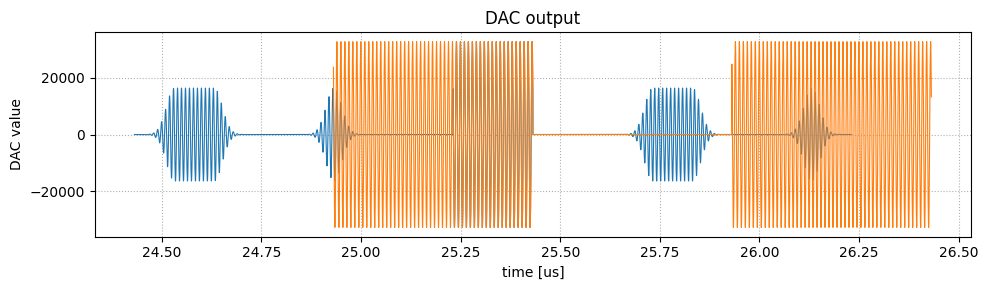

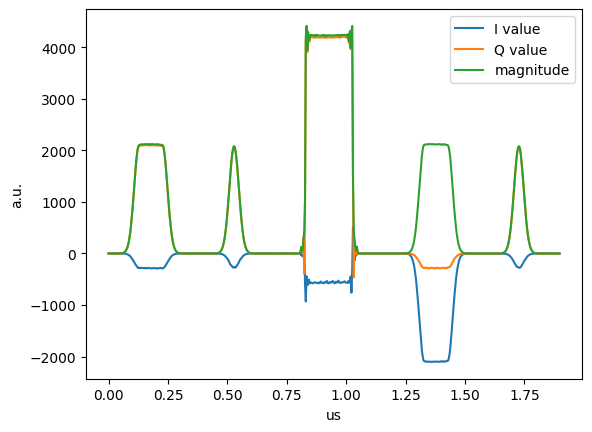

In [4]:
# emulator artifacts
OUT = ARTIFACTS_ROOT / 'multi_pulse'
OUT.mkdir(parents=True, exist_ok=True)
print(f'Artifacts -> {OUT}')
soc = soc.prepare_emu(memdir=OUT, build=False, trace=True)

## Run the emulator acquire path, which will generate the CSV output files
iq_list = prog.acquire_decimated(soc)

## Plot DAC waveform
QICKEmu_plot_dac(soc, OUT)

# Decimated I/Q -- mirror of cell 10 in 00_intro.ipynb
t       = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="magnitude")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

In [5]:
# print the program (ugly!)
print(prog)

macros:
	WriteReg(dst='s_core_w1', src=0)
	ConfigReadout(ch=0, name='myro', t=0, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x7fabe846eb50>}, t_regs={'t': 0})
	Delay(t=1.0, auto=True, gens=True, ros=True, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x7fabe846ebe0>}, t_regs={'t': 430})
	OpenLoop(n=1, name='reps')
	Trigger(ros=[0], tts=[], pins=[0], t=0.4, width=0.023251488095238096, ddr4=True, mr=False, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x7fabe846ed60>, 'width': <qick.asm_v2.QickParam object at 0x7fabe846ebb0>}, t_regs={'t': 172, 'width': 10}, outdict=defaultdict(<class 'int'>, {}), trigset={0, 9, 10})
	Pulse(ch=0, name='myflattop', t=0, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x7fabe846eca0>}, t_regs={'t': 0})
	Pulse(ch=0, name='mygaus', t=0.4, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x7fabe846ef70>}, t_regs={'t': 172})
	Pulse(ch=0, name='myconst', t=0.8, tag=None, t_params={'t': <qick.asm_v2.QickP